In [ ]:
# Install required packages
!pip install -q torch torchvision pytorch-lightning transformers matplotlib
!pip install -q opencv-python

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
from torchvision import transforms
from transformers import DetrForObjectDetection, DetrImageProcessor
from PIL import Image, ImageDraw, ImageFont

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

2025-04-28 07:30:05.994471: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745825406.211515      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745825406.275728      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Using device: cuda


In [2]:
# Load the pretrained DETR model with ResNet-50 backbone
model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")
model.to(device)
model.eval()

# Load the processor (for image preprocessing and postprocessing)
processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")

config.json:   0%|          | 0.00/4.59k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:2400: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:2400: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:2400: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pas

preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

In [3]:
from transformers import DetrForObjectDetection, DetrImageProcessor
import xml.etree.ElementTree as ET
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import glob
from tqdm import tqdm
from torchmetrics.detection.mean_ap import MeanAveragePrecision


In [4]:
COCO_CLASSES = [
    'N/A', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 
    'backpack', 'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase',
    'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat',
    'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle',
    'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana',
    'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A',
    'dining table', 'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse',
    'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster',
    'sink', 'refrigerator', 'N/A', 'book', 'clock', 'vase', 'scissors',
    'teddy bear', 'hair drier', 'toothbrush'
]


In [5]:
class VOCDataset(Dataset):
    def __init__(self, image_folder, annotation_folder, transforms=None):
        self.image_paths = sorted(glob.glob(f"{image_folder}/*.jpg"))
        self.annotation_paths = sorted(glob.glob(f"{annotation_folder}/*.xml"))
        self.transforms = transforms

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        annotation_path = self.annotation_paths[idx]
        
        tree = ET.parse(annotation_path)
        root = tree.getroot()
        
        annotations = []
        
        for obj in root.findall('object'):
            name = obj.find('name').text
            if name not in COCO_CLASSES:
                continue

            label = COCO_CLASSES.index(name)
            bndbox = obj.find('bndbox')
            xmin = float(bndbox.find('xmin').text)
            ymin = float(bndbox.find('ymin').text)
            xmax = float(bndbox.find('xmax').text)
            ymax = float(bndbox.find('ymax').text)
            width = xmax - xmin
            height = ymax - ymin

            annotations.append({
                "category_id": label,
                "bbox": [xmin, ymin, width, height],
                "area": width * height,
                "iscrowd": 0
            })
        
        target = {
            "image_id": idx,
            "annotations": annotations
        }
        
        if self.transforms:
            image = self.transforms(image)
        
        return image, target


In [6]:
transforms = T.Compose([
    T.Resize((800, 800)),
    T.ToTensor()
])
def collate_fn(batch):
    images, targets = list(zip(*batch))
    return list(images), list(targets)


In [ ]:
train_dataset = VOCDataset(
    image_folder="/kaggle/input/pascal-voc-2007-dataset/VOCdevkit2007/VOC2007/JPEGImages",
    annotation_folder="/kaggle/input/pascal-voc-2007-dataset/VOCdevkit2007/VOC2007/Annotations",
    transforms=transforms
)

train_loader = DataLoader(
    train_dataset, 
    batch_size=4, 
    shuffle=True, 
    collate_fn=collate_fn
)


In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

In [ ]:
from tqdm import tqdm

num_epochs = 1

model.train()
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    epoch_loss = 0.0
    num_batches = 0

    for images, targets in tqdm(train_loader, desc="Training", leave=False):
        encoding = processor(images=images, annotations=targets, return_tensors="pt")
        
        pixel_values = encoding["pixel_values"].to(device)
        labels = [{k: v.to(device) for k, v in t.items()} for t in encoding["labels"]]
        
        outputs = model(pixel_values=pixel_values, labels=labels)
        
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    print(f"Average Loss: {avg_loss:.4f}")
# Save model weights
save_path = "/kaggle/working/detr_finetuned.pth"
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")



In [7]:
# Load the model architecture first (must be same model)
from transformers import DetrForObjectDetection

model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")
model.load_state_dict(torch.load("/kaggle/input/detr-abhi/detr_finetuned.pth", map_location=device))
model.to(device)
model.eval()

print("Model loaded and ready for evaluation.")


Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
/tmp/ipykernel_31/3044954094.py:5: FutureWarning: You are using `torch.load` with `w

Model loaded and ready for evaluation.


In [8]:
val_dataset = VOCDataset(
    image_folder="/kaggle/input/pascal-voc-2007-dataset/VOCdevkit2007/VOC2007/JPEGImages",
    annotation_folder="/kaggle/input/pascal-voc-2007-dataset/VOCdevkit2007/VOC2007/Annotations",
    transforms=transforms
)

# Validation DataLoader
val_loader = DataLoader(
    val_dataset, 
    batch_size=4, 
    shuffle=False,  # No need to shuffle validation data
    collate_fn=collate_fn  # Keep collate_fn for proper handling of batch
)



In [13]:
# Map COCO class indices (1-90) to VOC indices (1-20). Returns 0 if no match.
COCO_TO_VOC = {
    5: 1,   # airplane -> aeroplane
    2: 2,   # bicycle -> bicycle
    16: 3,  # bird -> bird
    9: 4,   # boat -> boat
    44: 5,  # bottle -> bottle
    6: 6,   # bus -> bus
    3: 7,   # car -> car
    17: 8,  # cat -> cat
    62: 9,  # chair -> chair
    21: 10, # cow -> cow
    67: 11, # dining table -> diningtable
    18: 12, # dog -> dog
    19: 13, # horse -> horse
    4: 14,  # motorcycle -> motorbike
    1: 15,  # person -> person
    64: 16, # potted plant -> pottedplant
    20: 17, # sheep -> sheep
    63: 18, # couch -> sofa
    7: 19,  # train -> train
    72: 20  # tv -> tvmonitor
}

VOC_CLASS_NAMES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus',
    'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse',
    'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]

In [10]:
# See what your dataset actually returns
sample = val_dataset[0]
print("Image type:", type(sample[0]))
print("Image shape:" if isinstance(sample[0], torch.Tensor) else "Image size:", 
      sample[0].shape if isinstance(sample[0], torch.Tensor) else sample[0].size)

Image type: <class 'torch.Tensor'>
Image shape: torch.Size([3, 800, 800])


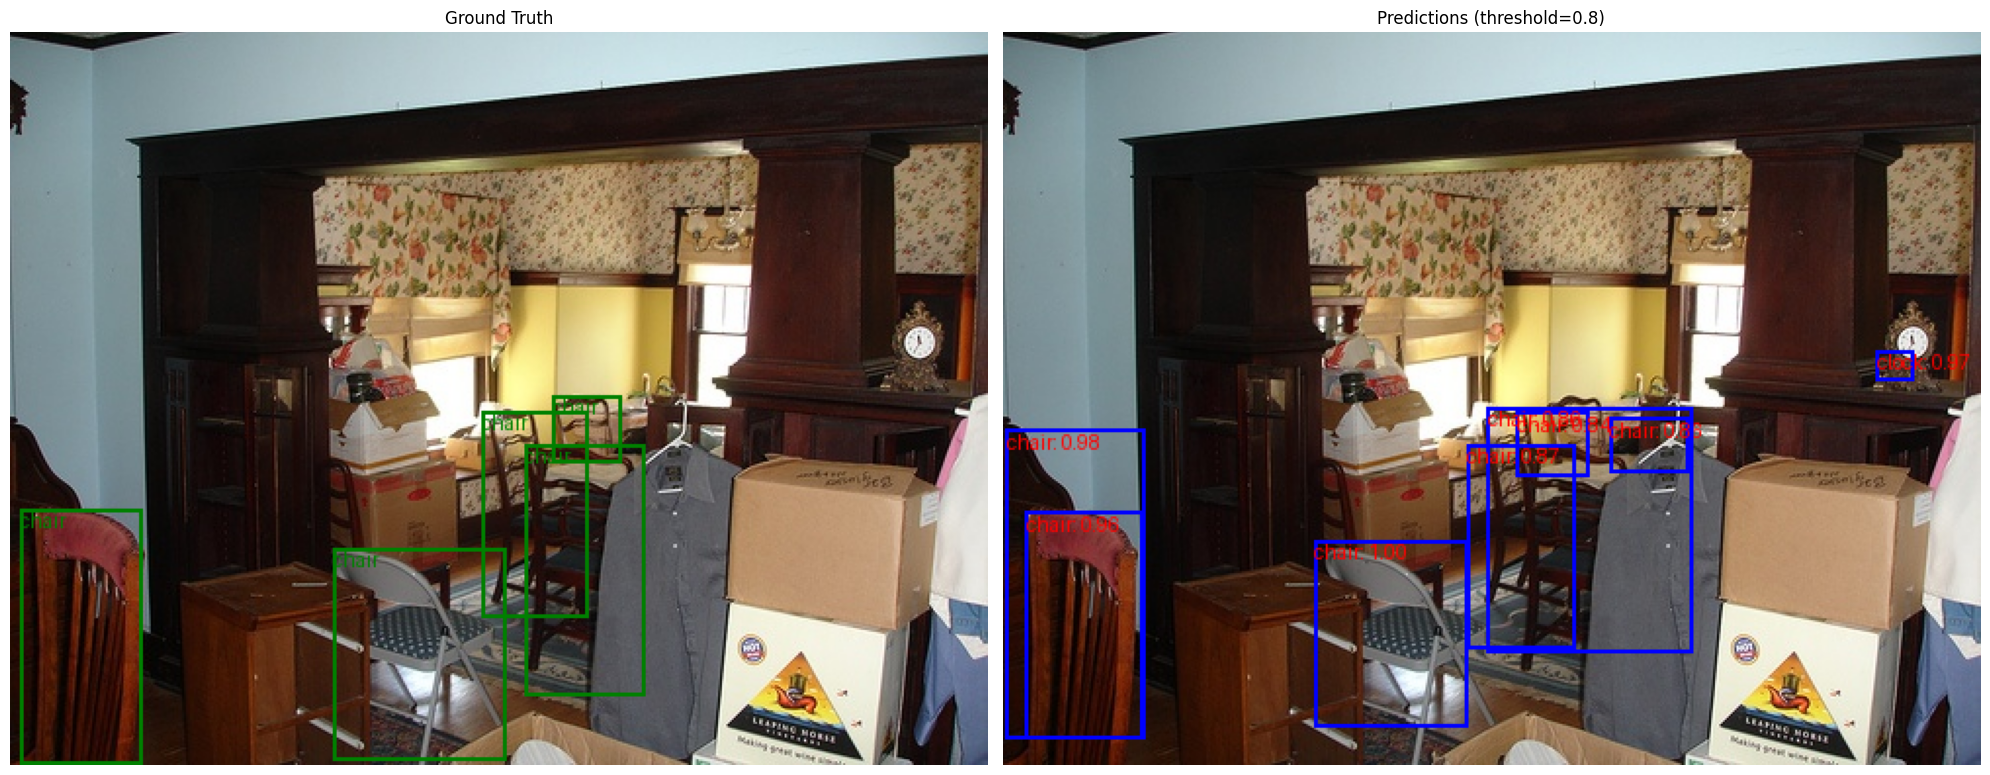

In [11]:
import torch
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from transformers import DetrForObjectDetection, DetrImageProcessor

# COCO class names (91 classes including background)
COCO_CLASSES = [
    'N/A', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 
    'backpack', 'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase',
    'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat',
    'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle',
    'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana',
    'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A',
    'dining table', 'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse',
    'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster',
    'sink', 'refrigerator', 'N/A', 'book', 'clock', 'vase', 'scissors',
    'teddy bear', 'hair drier', 'toothbrush'
]

def visualize_predictions(image, outputs, threshold=0.7):
    """Visualize predictions with class labels and confidence scores"""
    # Convert to PIL if needed
    if isinstance(image, torch.Tensor):
        image = Image.fromarray(image.cpu().numpy().astype(np.uint8))
    
    draw = ImageDraw.Draw(image)
    width, height = image.size
    
    # Process outputs
    results = processor.post_process_object_detection(
        outputs, 
        threshold=threshold,
        target_sizes=[(height, width)]
    )[0]
    
    # Draw predictions
    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        box = box.tolist()
        label_text = f"{COCO_CLASSES[label]}: {score:.2f}"
        
        draw.rectangle(box, outline="blue", width=2)
        draw.text((box[0], box[1]), label_text, fill="red")
    
    return image
    
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

def plot_ground_truth(image_path, annotation_path):
    """Plot ground truth bounding boxes from Pascal VOC annotation"""
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)
    
    # Parse VOC annotation file
    tree = ET.parse(annotation_path)
    root = tree.getroot()
    
    for obj in root.findall('object'):
        name = obj.find('name').text
        bndbox = obj.find('bndbox')
        xmin = int(bndbox.find('xmin').text)
        ymin = int(bndbox.find('ymin').text)
        xmax = int(bndbox.find('xmax').text)
        ymax = int(bndbox.find('ymax').text)
        
        # Draw ground truth box
        draw.rectangle([xmin, ymin, xmax, ymax], outline="green", width=2)
        draw.text((xmin, ymin), name, fill="green")
    
    return image

def run_detection_with_gt(image_path, threshold=0.7):
    """Run detection and show both ground truth and predictions"""
    # Get corresponding annotation path
    annotation_path = image_path.replace('JPEGImages', 'Annotations').replace('.jpg', '.xml')
    
    # Create figure
    plt.figure(figsize=(20, 10))
    
    # 1. Show ground truth
    plt.subplot(1, 2, 1)
    gt_image = plot_ground_truth(image_path, annotation_path)
    plt.imshow(gt_image)
    plt.title("Ground Truth")
    plt.axis('off')
    
    # 2. Show predictions
    plt.subplot(1, 2, 2)
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    pred_image = visualize_predictions(image, outputs, threshold)
    plt.imshow(pred_image)
    plt.title(f"Predictions (threshold={threshold})")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Example usage
image_path = "/kaggle/input/pascal-voc-2007-dataset/VOCdevkit2007/VOC2007/JPEGImages/000005.jpg"
run_detection_with_gt(image_path, threshold=0.8)


In [23]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import torch

# initialize mAP metric
metric = MeanAveragePrecision().to(device)
metric.reset()
model.eval()

# parameters
threshold = 0.001   # lower threshold to catch more preds
max_batches = 3     # number of batches to accumulate

preds, gts = [], []

for batch_idx, (images, targets) in enumerate(val_loader):
    inputs = processor(images=list(images), return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    # post‐process with lower threshold
    results = processor.post_process_object_detection(
        outputs,
        threshold=threshold,
        target_sizes=[(img.shape[1], img.shape[2]) for img in images]
    )

    # debug print: how many preds vs gts per image
    for i, res in enumerate(results):
        print(f"Batch {batch_idx}, Img {i}: preds={res['boxes'].shape[0]}, gts={len(targets[i]['annotations'])}")

        preds.append({
            "boxes":  res["boxes"].to(device),
            "scores": res["scores"].to(device),
            "labels": res["labels"].to(device),
        })
        annos = targets[i]["annotations"]
        if annos:
            b = torch.tensor([a["bbox"] for a in annos], dtype=torch.float32, device=device)
            boxes = torch.stack([b[:,0], b[:,1], b[:,0]+b[:,2], b[:,1]+b[:,3]], dim=1)
            labels = torch.tensor([a["category_id"] for a in annos], dtype=torch.int64, device=device)
        else:
            boxes = torch.zeros((0,4), dtype=torch.float32, device=device)
            labels = torch.zeros((0,),   dtype=torch.int64, device=device)

        gts.append({"boxes": boxes, "labels": labels})

    if batch_idx + 1 >= max_batches:
        break

# compute mAP
metric.update(preds, gts)
map_dict = metric.compute()
print(f"mAP@IoU=0.50:0.95 (threshold={threshold}):", map_dict["map"])


Batch 0, Img 0: preds=100, gts=5
Batch 0, Img 1: preds=100, gts=1
Batch 0, Img 2: preds=100, gts=4
Batch 0, Img 3: preds=100, gts=1
Batch 1, Img 0: preds=100, gts=1
Batch 1, Img 1: preds=100, gts=2
Batch 1, Img 2: preds=100, gts=2
Batch 1, Img 3: preds=100, gts=1
Batch 2, Img 0: preds=100, gts=4
Batch 2, Img 1: preds=100, gts=6
Batch 2, Img 2: preds=100, gts=1
Batch 2, Img 3: preds=100, gts=1
mAP@IoU=0.50:0.95 (threshold=0.001): tensor(0.0009)
